In [24]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.decomposition import PCA
import plotly.graph_objects as go


# Load colors from JSON
with open('colors.json', 'r') as f:
    colors = json.load(f)

In [25]:
def plot_color_grid(color_list, cols=10):
    """
    Draws a 2D grid of color swatches.
    
    Args:
        color_list (list): A list of color dictionaries, e.g., [{'r': 255, 'g': 0, 'b': 0}, ...].
        cols (int, optional): The number of columns in the grid. Defaults to 10.
    """
    rows = (len(color_list) + cols - 1) // cols
    
    # Set up the figure. We make rows slightly taller (1.2) to fit text
    fig, ax = plt.subplots(figsize=(cols, rows * 1.2))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows * 1.2)
    ax.axis('off')
    ax.invert_yaxis() # Top-to-bottom layout
    ax.set_aspect('equal') # Enforce exactly 1:1 aspect ratio so squares stay square
    
    for i, color in enumerate(color_list):
        x = i % cols
        y = (i // cols) * 1.2 # Multiply row index by 1.2 for spacing
        
        hex_color = f"#{color['r']:02x}{color['g']:02x}{color['b']:02x}"
        
        # Draw the color swatch as a perfect 0.8 x 0.8 square
        rect = patches.Rectangle((x + 0.1, y + 0.1), 0.9, 0.8, facecolor=hex_color, edgecolor='none')
        ax.add_patch(rect)
        
        # Draw the index number centered below the swatch (larger Y is visually lower)
        ax.text(x + 0.55, y + 1.05, str(i + 1), ha='center', va='center', fontsize=10, color='black')
    
    plt.show()

def plot_3d_path(x, y, z, colors, title, xaxis_title, yaxis_title, zaxis_title, path_name="Path"):
    """
    Creates an interactive 3D scatter plot of colors connected by a continuous path.
    
    Args:
        x, y, z (array-like): Coordinates for each color point in the 3D space.
        colors (list): List of RGB color dictionaries corresponding to the coordinates.
        title (str): Title of the plot.
        xaxis_title, yaxis_title, zaxis_title (str): Labels for the X, Y, and Z axes.
        path_name (str, optional): Legend name for the continuous path line. Defaults to "Path".
    """
    fig = go.Figure()
    scatter_colors = [f"#{c['r']:02x}{c['g']:02x}{c['b']:02x}" for c in colors]
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='markers', marker=dict(size=6, color=scatter_colors, line=dict(color='black', width=1)), name='Colors'))
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='lines', line=dict(color='gray', width=2), name=path_name))
    fig.update_layout(title=title, scene=dict(xaxis_title=xaxis_title, yaxis_title=yaxis_title, zaxis_title=zaxis_title), margin=dict(l=0, r=0, b=0, t=40))
    fig.show()

def plot_3d_projection(x, y, z, colors, proj_line_x, proj_line_y, proj_line_z, proj_pts_x, proj_pts_y, proj_pts_z, title, xaxis_title, yaxis_title, zaxis_title, proj_name="Projection"):
    """
    Creates an interactive 3D scatter plot showing colors projected onto a principal axis.
    
    Args:
        x, y, z (array-like): Original coordinates for each color point.
        colors (list): List of RGB color dictionaries corresponding to the coordinates.
        proj_line_x, proj_line_y, proj_line_z (list): Coordinates defining the start and end of the main projection line.
        proj_pts_x, proj_pts_y, proj_pts_z (array-like): Projected coordinates for each point on the main line.
        title (str): Title of the plot.
        xaxis_title, yaxis_title, zaxis_title (str): Labels for the X, Y, and Z axes.
        proj_name (str, optional): Legend name for the main projection line. Defaults to "Projection".
    """
    fig = go.Figure()
    scatter_colors = [f"#{c['r']:02x}{c['g']:02x}{c['b']:02x}" for c in colors]
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='markers', marker=dict(size=5, color=scatter_colors, line=dict(color='black', width=1)), name='Colors'))
    fig.add_trace(go.Scatter3d(x=proj_line_x, y=proj_line_y, z=proj_line_z, mode='lines', line=dict(color='red', width=5), name=proj_name))
    for i in range(len(x)):
        fig.add_trace(go.Scatter3d(x=[x[i], proj_pts_x[i]], y=[y[i], proj_pts_y[i]], z=[z[i], proj_pts_z[i]], mode='lines', line=dict(color='gray', width=2, dash='dot'), showlegend=False))
    fig.update_layout(title=title, scene=dict(xaxis_title=xaxis_title, yaxis_title=yaxis_title, zaxis_title=zaxis_title), margin=dict(l=0, r=0, b=0, t=40))
    fig.show()


# Baseline: RGB -> HSV -> sort by Hue

In [26]:
# Convert RGB to HSV and sort by Hue using OpenCV
def sort_by_hue(color):
    # OpenCV expects a 3D numpy array for color conversion (e.g., shape (1, 1, 3) for a single pixel)
    rgb_pixel = np.uint8([[[color['r'], color['g'], color['b']]]])
    hsv_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2HSV)
    
    # Extract the Hue value (index 0)
    h = hsv_pixel[0][0][0]
    return int(h)

sorted_colors = sorted(colors, key=sort_by_hue)

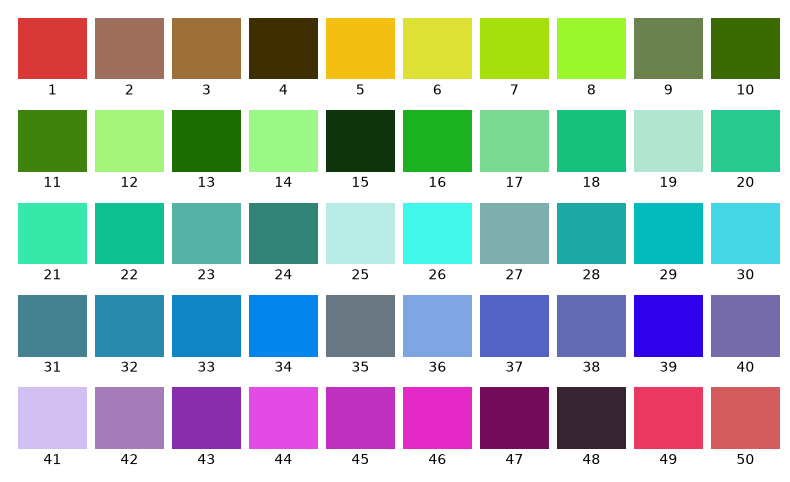

In [27]:
# Display colors in a grid
plot_color_grid(sorted_colors)


## Visualize HSV Space and Hue Projection

In [28]:
# Get HSV values for all original colors
hsv_colors = []
for c in colors:
    rgb_pixel = np.uint8([[[c['r'], c['g'], c['b']]]])
    hsv_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2HSV)
    hsv_colors.append(hsv_pixel[0][0])
hsv_colors = np.array(hsv_colors)

H = hsv_colors[:, 0]
S = hsv_colors[:, 1]
V = hsv_colors[:, 2]

mean_S = S.mean()
mean_V = V.mean()
min_H = H.min()
max_H = H.max()

proj_pts_x = H
proj_pts_y = np.full_like(H, mean_S)
proj_pts_z = np.full_like(H, mean_V)

plot_3d_projection(
    H, S, V, colors,
    [min_H, max_H], [mean_S, mean_S], [mean_V, mean_V],
    proj_pts_x, proj_pts_y, proj_pts_z,
    title='Colors in HSV space with Hue 1D Projection',
    xaxis_title='H (Hue)', yaxis_title='S (Saturation)', zaxis_title='V (Value)',
    proj_name='Hue 1D Projection Line'
)


# Alt Method 1: RGB -> CIELAB -> sort by PCA in 1D

In [29]:
# Convert RGB to LAB
def rgb_to_lab(color):
    rgb_pixel = np.uint8([[[color['r'], color['g'], color['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)
    return lab_pixel[0][0]

# Get all LAB values
lab_colors = np.array([rgb_to_lab(c) for c in colors])

# Apply PCA to find the principal axis
pca = PCA(n_components=1)
pca_values = pca.fit_transform(lab_colors)

# Combine colors with their 1D PCA values and sort
colors_with_pca = list(zip(colors, pca_values.flatten()))
colors_with_pca.sort(key=lambda x: x[1])
pca_sorted_colors = [c[0] for c in colors_with_pca]

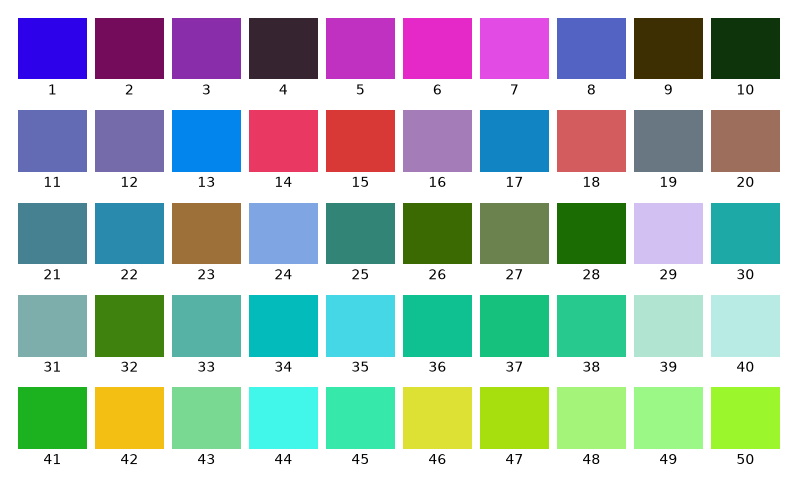

In [30]:
# Display colors in a grid
plot_color_grid(pca_sorted_colors)


## Visualize CIELAB Space and PCA Projection

In [31]:
# Extract L, A, B values
L = lab_colors[:, 0]
A = lab_colors[:, 1]
B = lab_colors[:, 2]

mean_lab = pca.mean_
component = pca.components_[0]
min_val = pca_values.min()
max_val = pca_values.max()
line_pts = np.array([mean_lab + min_val * component, mean_lab + max_val * component])

proj_pts = mean_lab + pca_values * component
proj_pts_x = proj_pts[:, 1]
proj_pts_y = proj_pts[:, 2]
proj_pts_z = proj_pts[:, 0]

plot_3d_projection(
    A, B, L, colors,
    line_pts[:, 1], line_pts[:, 2], line_pts[:, 0],
    proj_pts_x, proj_pts_y, proj_pts_z,
    title='Colors in CIELAB space with PCA 1D Projection',
    xaxis_title='A* (Green-Red)', yaxis_title='B* (Blue-Yellow)', zaxis_title='L* (Lightness)',
    proj_name='PCA 1D Projection Line'
)


# Alt Method 2: RGB -> CIELAB -> sort by L

In [32]:
# Convert RGB to HSV and sort by Hue using OpenCV
def sort_by_lightness(color):
    # OpenCV expects a 3D numpy array for color conversion (e.g., shape (1, 1, 3) for a single pixel)
    rgb_pixel = np.uint8([[[color['r'], color['g'], color['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)
    
    # Extract the Hue value (index 0)
    l = lab_pixel[0][0][0]
    return int(l)

sorted_lab_colors = sorted(colors, key=sort_by_lightness)

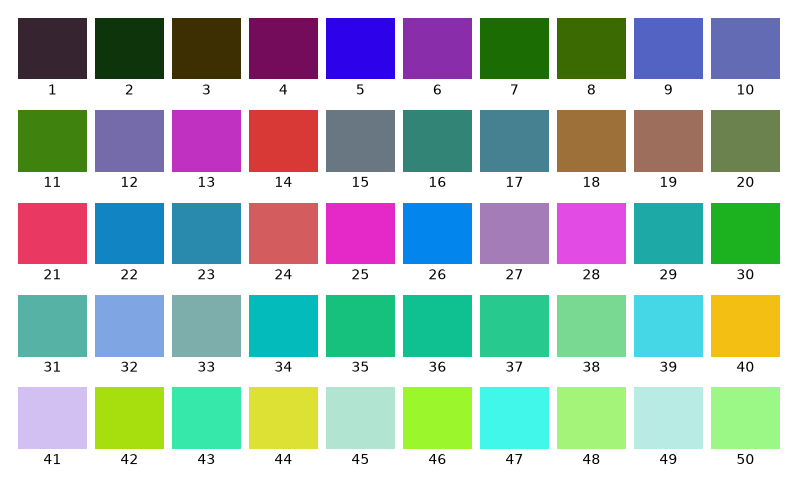

In [33]:
plot_color_grid(sorted_lab_colors)

# Method 3: RGB -> CIELAB -> sort by Hilbert Curve

**What are Hilbert Curves?**
A Hilbert curve is a continuous fractal space-filling curve. It maps a 1D line into a multi-dimensional space (e.g., 2D or 3D) in a way that preserves locality. This means that points that are close to each other in the 3D space will generally be close to each other on the 1D Hilbert curve. 

**How it's used here:**
We map our 3D CIELAB color values (L*, A*, B*) onto a 3D grid. We then calculate the 1D distance (Hilbert index) for each color along the curve. Sorting the colors by this 1D index creates a sequence that smoothly transitions through the 3D color space, keeping perceptually similar colors close together!

In [34]:
from hilbertcurve.hilbertcurve import HilbertCurve

# We use p=8 to create a grid of 2^8 = 256 buckets per dimension.
# n=3 for the 3 dimensions (L, A, B)
hilbert_curve = HilbertCurve(p=8, n=3)

def get_hilbert_distance(color):
    rgb_pixel = np.uint8([[[color['r'], color['g'], color['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
    
    L, A, B = lab_pixel
    
    # Conveniently, OpenCV's 8-bit COLOR_RGB2LAB already normalizes the values to 0-255:
    # L is scaled to 0-255, and A/B are shifted by +128 to fit 0-255.
    # This perfectly matches our p=8 grid size!
    
    # Calculate Hilbert index
    distance = hilbert_curve.distance_from_point([L, A, B])
    return distance

# Sort colors by their Hilbert distance
hilbert_sorted_colors = sorted(colors, key=get_hilbert_distance)

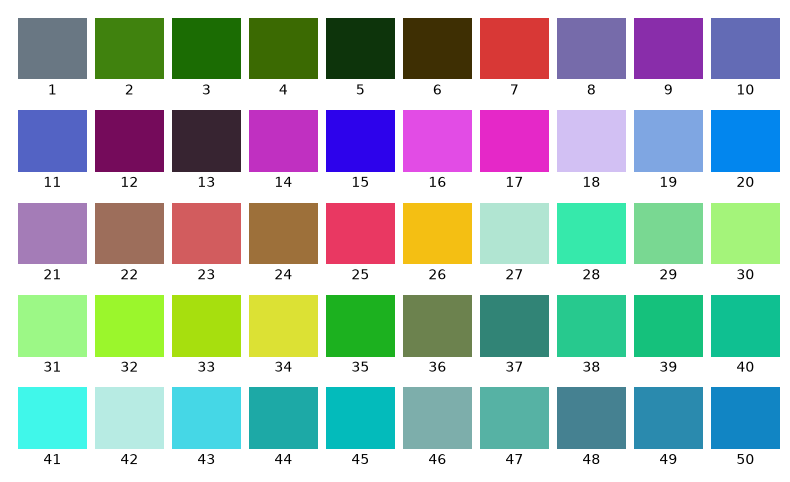

In [35]:
# Display colors in a grid
plot_color_grid(hilbert_sorted_colors)

## Visualize Hilbert Curve Path through CIELAB Space

In [36]:
# Get LAB values for the sorted colors
sorted_lab_colors = []
for c in hilbert_sorted_colors:
    rgb_pixel = np.uint8([[[c['r'], c['g'], c['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
    sorted_lab_colors.append(lab_pixel)

sorted_lab_colors = np.array(sorted_lab_colors)

H_L = sorted_lab_colors[:, 0]
H_A = sorted_lab_colors[:, 1]
H_B = sorted_lab_colors[:, 2]

plot_3d_path(
    H_A, H_B, H_L, hilbert_sorted_colors,
    title='Hilbert Curve Path through CIELAB Space',
    xaxis_title='A* (Green-Red)', yaxis_title='B* (Blue-Yellow)', zaxis_title='L* (Lightness)',
    path_name='Hilbert Path'
)


# Method 4: RGB -> CIELAB -> Travelling Salesperson Problem (TSP)

**The Generic Travelling Salesperson Problem:**
The Travelling Salesperson Problem (TSP) asks the following question: "Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city?" It is an NP-hard problem, meaning there is no known algorithm to solve it perfectly in polynomial time for a large number of nodes.

**How we phrase Color Sorting as a TSP:**
In our scenario, the "cities" are our colors, and the "distances" are the perceptual differences between these colors, calculated using Euclidean distance in the 3D CIELAB color space. 
By solving the TSP on our colors, we are searching for the sequence that minimizes the total color difference along the path. 

Because finding the exact optimal path is too computationally expensive, we use an approximation algorithm called the **Christofides algorithm**, which guarantees a path that is at most 1.5 times the length of the optimal path. Finally, because TSP creates a closed loop, we break the loop at the longest edge to create an open path of sorted colors.

In [37]:
import networkx as nx
from itertools import combinations
from networkx.algorithms import approximation

# Convert colors to LAB for distance calculations
tsp_lab_colors = []
for c in colors:
    rgb_pixel = np.uint8([[[c['r'], c['g'], c['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
    tsp_lab_colors.append(lab_pixel.astype(float))

# Build a complete graph with distances as edge weights
G = nx.Graph()
for i in range(len(colors)):
    G.add_node(i)

for i, j in combinations(range(len(colors)), 2):
    # Euclidean distance in CIELAB space
    dist = np.linalg.norm(tsp_lab_colors[i] - tsp_lab_colors[j])
    G.add_edge(i, j, weight=dist)

# Solve the TSP using Christofides algorithm
# This returns a closed loop of node indices
tsp_cycle = approximation.traveling_salesman_problem(G, weight='weight', cycle=True)

# Break the loop at the longest edge to create an open path
max_edge_weight = -1
break_index = 0
for i in range(len(tsp_cycle) - 1):
    u = tsp_cycle[i]
    v = tsp_cycle[i+1]
    w = G[u][v]['weight']
    if w > max_edge_weight:
        max_edge_weight = w
        break_index = i

# Reorder the cycle into a path starting after the longest edge
tsp_path = tsp_cycle[break_index+1:-1] + tsp_cycle[:break_index+1]

tsp_sorted_colors = [colors[i] for i in tsp_path]

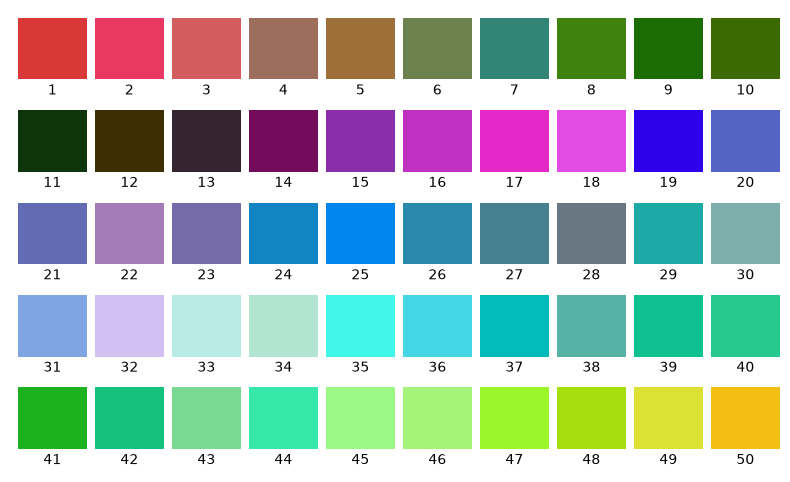

In [38]:
# Display colors in a grid
plot_color_grid(tsp_sorted_colors)

## Visualize TSP Path through CIELAB Space

In [39]:
# Extract LAB values in the sorted order
path_lab_colors = np.array([tsp_lab_colors[i] for i in tsp_path])

T_L = path_lab_colors[:, 0]
T_A = path_lab_colors[:, 1]
T_B = path_lab_colors[:, 2]

plot_3d_path(
    T_A, T_B, T_L, tsp_sorted_colors,
    title='TSP Path through CIELAB Space',
    xaxis_title='A* (Green-Red)', yaxis_title='B* (Blue-Yellow)', zaxis_title='L* (Lightness)',
    path_name='TSP Path'
)


# Method 5: RGB -> CIELCh -> Travelling Salesperson Problem (TSP) with Hue Weighting

**What is CIELCh?**
CIELCh is a cylindrical representation of the CIELAB color space. Instead of using Cartesian coordinates (L*, a*, b*), it uses:
- **L***: Lightness
- **C***: Chroma (colorfulness / saturation)
- **h°**: Hue angle (the actual color tone)

**Why weight Hue?**
In standard CIELAB/CIELCh, Euclidean distances treat changes in lightness, chroma, and hue equally. However, human vision is often more sensitive to changes in hue when trying to organize colors logically. By converting to CIELCh, we can calculate the distance between colors and apply an artificial multiplier (weight) to the Hue difference. This forces the TSP algorithm to prioritize keeping similar hues together, even if it means larger jumps in lightness or chroma.

In [40]:
import math

hue_weight = 2.0 # Extra weightage for hue differences
lightness_weight = 1.5 # Extra weightage for hue differences

# Convert colors to LCh
tsp_lch_colors = []
for c in colors:
    rgb_pixel = np.uint8([[[c['r'], c['g'], c['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
    
    # Convert OpenCV 8-bit LAB to standard LAB ranges
    # L is 0-100, A and B are -128 to 127
    L_real = float(lab_pixel[0]) * 100.0 / 255.0
    a_real = float(lab_pixel[1]) - 128.0
    b_real = float(lab_pixel[2]) - 128.0
    
    # Convert LAB to LCh
    C = math.sqrt(a_real**2 + b_real**2)
    h = math.atan2(b_real, a_real) # radians
    
    tsp_lch_colors.append((L_real, C, h))

# Build graph
G_lch = nx.Graph()
for i in range(len(colors)):
    G_lch.add_node(i)

for i, j in combinations(range(len(colors)), 2):
    L1, C1, h1 = tsp_lch_colors[i]
    L2, C2, h2 = tsp_lch_colors[j]
    
    dL = L1 - L2
    dC = C1 - C2
    
    # Angular difference wrapped between -pi and pi
    dh = h1 - h2
    dh = (dh + math.pi) % (2 * math.pi) - math.pi
    
    # Metric Hue difference (standard colorimetry formula)
    dH = 2 * math.sqrt(C1 * C2) * math.sin(dh / 2.0)
    
    # Weighted distance
    dist = math.sqrt(dL**2 + dC**2 + (hue_weight * dH)**2)
    
    G_lch.add_edge(i, j, weight=dist)

# Solve TSP
tsp_cycle_lch = approximation.traveling_salesman_problem(G_lch, weight='weight', cycle=True)

# Break the loop at the longest edge
max_edge_weight = -1
break_index = 7
# for i in range(len(tsp_cycle_lch) - 1):
#     u = tsp_cycle_lch[i]
#     v = tsp_cycle_lch[i+1]
#     w = G_lch[u][v]['weight']
#     if w > max_edge_weight:
#         max_edge_weight = w
#         break_index = i

tsp_path_lch = tsp_cycle_lch[break_index+1:-1] + tsp_cycle_lch[:break_index+1]
lch_sorted_colors = [colors[i] for i in tsp_path_lch]

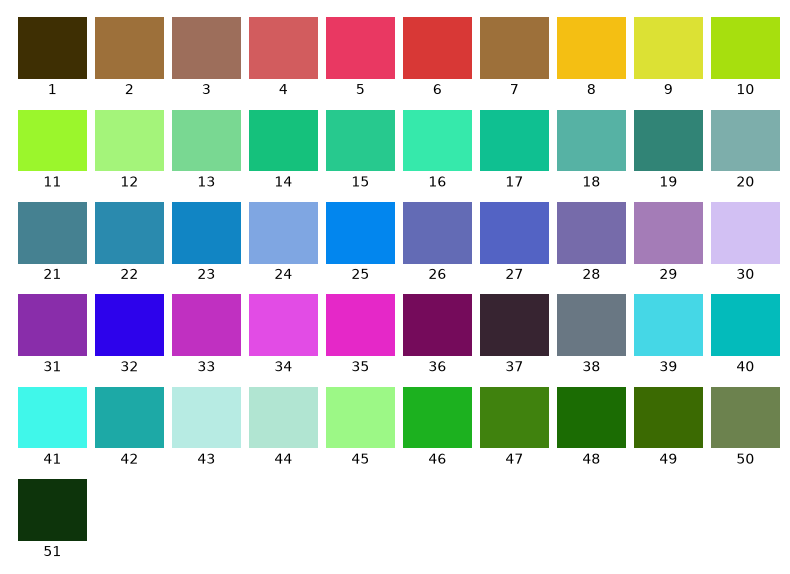

In [41]:
# Display colors in a grid
plot_color_grid(lch_sorted_colors)

## Visualize Weighted TSP Path through CIELAB Space

In [42]:
# We visualize the path in the standard LAB space to see how the hue weighting altered the route compared to Method 4
path_lab_colors_lch = []
for c in lch_sorted_colors:
    rgb_pixel = np.uint8([[[c['r'], c['g'], c['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
    path_lab_colors_lch.append(lab_pixel.astype(float))
path_lab_colors_lch = np.array(path_lab_colors_lch)

LCH_L = path_lab_colors_lch[:, 0]
LCH_A = path_lab_colors_lch[:, 1]
LCH_B = path_lab_colors_lch[:, 2]

plot_3d_path(
    LCH_A, LCH_B, LCH_L, lch_sorted_colors,
    title='LCh Hue-Weighted TSP Path through CIELAB Space',
    xaxis_title='A* (Green-Red)', yaxis_title='B* (Blue-Yellow)', zaxis_title='L* (Lightness)',
    path_name='LCh Hue-Weighted Path'
)


## Visualize in 'Unrolled' CIELCh Space
Geometrically, CIELAB and CIELCh occupy the exact same 3D color space—LAB uses Cartesian coordinates (X,Y) while LCh uses Polar coordinates (Radius, Angle) to map the exact same points. 

However, we can "unroll" the cylinder into a rectangular graph where the axes explicitly represent Hue, Chroma, and Lightness as flat dimensions. This makes it very easy to see how the TSP algorithm prioritized staying within similar Hue bands (the X-axis) before jumping across to different colors!

In [43]:
import math

# Extract L, C, h values in the sorted order
sorted_L = []
sorted_C = []
sorted_h = []

for c in lch_sorted_colors:
    rgb_pixel = np.uint8([[[c['r'], c['g'], c['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
    
    L_real = float(lab_pixel[0]) * 100.0 / 255.0
    a_real = float(lab_pixel[1]) - 128.0
    b_real = float(lab_pixel[2]) - 128.0
    
    C = math.sqrt(a_real**2 + b_real**2)
    h = math.degrees(math.atan2(b_real, a_real))
    if h < 0:
        h += 360
        
    sorted_L.append(L_real)
    sorted_C.append(C)
    sorted_h.append(h)

plot_3d_path(
    sorted_h, sorted_C, sorted_L, lch_sorted_colors,
    title='Unrolled CIELCh Space (Hue vs Chroma vs Lightness)',
    xaxis_title='Hue Angle (0-360°)', yaxis_title='Chroma (Saturation)', zaxis_title='Lightness (L*)',
    path_name='LCh Hue-Weighted Path'
)


# Method 6: Macro-Binning by Hue & Constrained TSP

**Step 1: Macro-Binning by Hue**
We divide the colors into 7 bins. First, all colors with very low saturation (Chroma < 15) are filtered into a `Neutrals` bin. The remaining colors are sorted into 6 symmetrical 60° slices of the color wheel (Reds, Yellows, Greens, Cyans, Blues, Magentas).

**Step 2: Order the Bins**
We establish a fixed sequence to traverse the color wheel: Neutrals -> Reds -> Yellows -> Greens -> Cyans -> Blues -> Magentas.

**Step 3: Constrained TSP (Hamiltonian Path with Forced Start)**
Instead of just running a closed-loop TSP on everything, we run a TSP *inside* each bin. To ensure smooth transitions between bins, we use an open-loop TSP constraint:
1. We sort the first bin (Neutrals).
2. We find the color in the *next* bin (Reds) that is geometrically closest to the very last color of the Neutrals bin. This closest red color becomes the **Forced Start Node** for the Red bin's TSP.
3. We use a 'Dummy Node' trick to force the Simulated Annealing TSP algorithm to produce an open path that strictly originates from this start node.
4. We repeat this chain reaction for all subsequent bins!

In [44]:
import math
import networkx as nx
from networkx.algorithms import approximation

def get_lch(color):
    rgb_pixel = np.uint8([[[color['r'], color['g'], color['b']]]])
    lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
    L = float(lab_pixel[0]) * 100.0 / 255.0
    A = float(lab_pixel[1]) - 128.0
    B = float(lab_pixel[2]) - 128.0
    C = math.sqrt(A**2 + B**2)
    h = math.degrees(math.atan2(B, A))
    if h < 0: h += 360
    return L, A, B, C, h

# 1. Macro-binning
bin_order = ['Neutrals', 'Reds', 'Yellows', 'Greens', 'Cyans', 'Blues', 'Magentas']
bin_colors = {b: [] for b in bin_order}
lch_map = {}

for c in colors:
    L, A, B, C, h = get_lch(c)
    lch_map[id(c)] = np.array([L, A, B])
    
    if C < 15:
        bin_colors['Neutrals'].append(c)
    elif h >= 330 or h < 30:
        bin_colors['Reds'].append(c)
    elif 30 <= h < 90:
        bin_colors['Yellows'].append(c)
    elif 90 <= h < 150:
        bin_colors['Greens'].append(c)
    elif 150 <= h < 210:
        bin_colors['Cyans'].append(c)
    elif 210 <= h < 270:
        bin_colors['Blues'].append(c)
    else: # 270 to 330
        bin_colors['Magentas'].append(c)

def extract_path(cycle, start_idx):
    cycle = cycle[:-1]
    idx = cycle.index('Dummy')
    shifted = cycle[idx+1:] + cycle[:idx]
    if shifted[-1] == start_idx:
        shifted.reverse()
    return shifted

def solve_constrained_tsp(bin_list, start_color):
    if not bin_list: return []
    if len(bin_list) == 1: return bin_list
    if len(bin_list) == 2:
        if start_color is not None and bin_list[1] == start_color:
            return [bin_list[1], bin_list[0]]
        return bin_list
        
    G = nx.Graph()
    for i in range(len(bin_list)):
        G.add_node(i)
        
    for i in range(len(bin_list)):
        for j in range(i+1, len(bin_list)):
            dist = np.linalg.norm(lch_map[id(bin_list[i])] - lch_map[id(bin_list[j])])
            G.add_edge(i, j, weight=dist)
            
    if start_color is not None:
        start_idx = bin_list.index(start_color)
        G.add_node('Dummy')
        for i in range(len(bin_list)):
            if i == start_idx:
                G.add_edge('Dummy', i, weight=-1e6)
            else:
                G.add_edge('Dummy', i, weight=0)
                
        greedy = approximation.greedy_tsp(G, weight='weight')
        sa = approximation.simulated_annealing_tsp(G, init_cycle=greedy, weight='weight', max_iterations=1000)
        path = extract_path(sa, start_idx)
    else:
        greedy = approximation.greedy_tsp(G, weight='weight')
        sa = approximation.simulated_annealing_tsp(G, init_cycle=greedy, weight='weight', max_iterations=1000)
        # Convert cycle to open path by breaking longest edge
        max_w = -1
        break_idx = 0
        for i in range(len(sa) - 1):
            u, v = sa[i], sa[i+1]
            w = G[u][v]['weight']
            if w > max_w:
                max_w = w
                break_idx = i
        path = sa[break_idx+1:-1] + sa[:break_idx+1]
        
    return [bin_list[i] for i in path]

# 2 & 3. Process bins in order with bridge connections
final_sorted_colors = []
last_color = None

for b in bin_order:
    current_bin = bin_colors[b]
    if not current_bin:
        continue
        
    start_color = None
    if last_color is not None:
        # Find closest color in the current bin to the last color of the previous bin
        min_dist = float('inf')
        for c in current_bin:
            dist = np.linalg.norm(lch_map[id(last_color)] - lch_map[id(c)])
            if dist < min_dist:
                min_dist = dist
                start_color = c
                
    sorted_bin = solve_constrained_tsp(current_bin, start_color)
    final_sorted_colors.extend(sorted_bin)
    last_color = sorted_bin[-1]


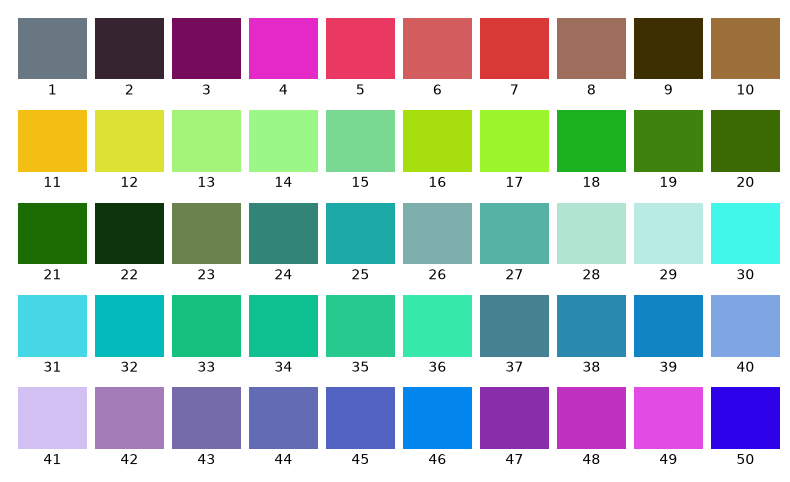

In [45]:
# Display colors in a grid
plot_color_grid(final_sorted_colors)

## Visualize Bin-Constrained TSP Path through CIELAB Space

In [46]:
# We visualize the path in the standard LAB space
path_lab_colors_binned = []
for c in final_sorted_colors:
    path_lab_colors_binned.append(lch_map[id(c)])
path_lab_colors_binned = np.array(path_lab_colors_binned)

BIN_L = path_lab_colors_binned[:, 0]
BIN_A = path_lab_colors_binned[:, 1]
BIN_B = path_lab_colors_binned[:, 2]

plot_3d_path(
    BIN_A, BIN_B, BIN_L, final_sorted_colors,
    title='Macro-Binned TSP Path through CIELAB Space',
    xaxis_title='A* (Green-Red)', yaxis_title='B* (Blue-Yellow)', zaxis_title='L* (Lightness)',
    path_name='Binned TSP Path'
)
